# Quantum Phase Estimation of a Qubitized Hamiltonian

## Part III. Qubitization and Quantum Phase Estimation

As a reminder, this kata consists of five parts:

1. [Part I](./QubitizedHamiltonianQPE_1_Hamiltonian.ipynb) walks you through the theoretical construction of the Hamiltonian we'll use as the example and its mathematical properties.
2. [Part II](./QubitizedHamiltonianQPE_2_BlockEncoding.ipynb) implements and validates the block encoding of this Hamiltonian as a Workbench program.
3. Part III (this notebook) builds on top of part II, implementing a qubitization iterate based on the block encoding and running quantum phase estimation to reveal some numeric properties of our Hamiltonian.
4. [Part IV](./QubitizedHamiltonianQPE_4_QRE.ipynb) demonstrates basic resource analysis of our program, using Workbench QRE tools and algorithmic insight to help optimize our solution.
5. [Part V](./QubitizedHamiltonianQPE_5_LandscapeAnalysis.ipynb) walks you through a more advanced example of resource analysis of our program, showing how to plot the algorithm's resource costs as a function of its parameters and to analyze any irregularities in its behavior.

In this notebook, we'll see how to convert the block encoding we've constructed in part II into a qubitization iterate and how to use it with quantum phase estimation.

## Qubitization

In the previous part of the kata, we built out all the components for the block encoding. Now, let's convert it to a qubitization iterate that we can use as the input to quantum phase estimation. This is easy to do: the only difference is adding the reflection about the $\ket{0}$ state of the auxiliary registers to the end of the Qubrick `_compute` method.

> We use library implementations from [PsiQDK Algorithms](https://construct.psiquantum.com/docs/psiqdk-algorithms/) for each component. If you want to bring in the Qubricks you've implemented in part II, you can do that too!

In [1]:
from psiqdk.workbench import Qubrick, Qubits

class QubitizedHamiltonianEncoding(Qubrick):

    def __init__(
        self,
        prepare,
        qrom,
        adder,
        **kwargs,
    ):
        self.prepare = prepare
        self.qrom = qrom
        self.adder = adder
        super().__init__(**kwargs)

    def _compute(
        self,
        state_reg: Qubits,
        coefficients_reg: Qubits,
        add_subtract_reg: Qubits,
        ctrl: int | Qubits=0,
    ):
        # PREPARE
        self.prepare.compute(coefficients_reg, cond=ctrl)  # Coefficients
        add_subtract_reg.had(cond=ctrl)                    # Add/subtract

        addends = self.alloc_temp_qreg(2, "addends")
        # QROM
        # computed handles uncomputation automatically when we exit the context manager
        with self.qrom.computed(coefficients_reg, addends, [1, 2, 3], ctrl=ctrl):
            # Apply the trick to make the SELECT self-inverse
            add_subtract_reg.x(cond=ctrl)
            
            # Apply adder
            adder.compute(state_reg, addends, ctrl=(add_subtract_reg == 0) | ctrl)
            # Apply subtractor as adjoint of adder
            adder.compute(state_reg, addends, ctrl=(add_subtract_reg == 1) | ctrl, dagger=True)

        # after uncomputing the QROM, addends are back in |0> and can be released
        addends.release()

        # UnPREPARE
        add_subtract_reg.had(cond=ctrl)                    # Add/subtract
        self.prepare.uncompute()                           # Coefficients

        # Reflection for qubitization
        (~coefficients_reg | ~add_subtract_reg).reflect(ctrl=ctrl)
        if ctrl:
            ctrl.reflect()

## Quantum phase estimation

Now that we've built our full qubitization iterate, it's time to use it to do some computation! Recall that our goal for this kata has been to perform energy estimation on different eigenstates of our Hamiltonian. The machinery we are going to use in order to do this is the quantum phase estimation (QPE) algorithm.

We won't go through the implementation of QPE in detail in this kata. If you're interested in the details, you can check out the [Quantum Phase Estimation kata](https://github.com/PsiQ/workbench-quantum-katas/tree/main/QPE). Vanilla QPE is implemented as a [standard Qubrick](https://construct.psiquantum.com/docs/psiqdk-algorithms/autoapi/psiqdk/algorithms/#psiqdk.algorithms.QPE) in PsiQDK Algorithms, so we'll just use that, plugging in our qubitization iterate as the `unitary` argument.

The setup is very similar to what we needed to compute the block encoding on its own, except this time we also need to allocate another register into which we are going to load our estimate of the energy. Additionally, if we just prepare any old state (like the computational basis state from part II), we won't get any sensible output &mdash; we'll just project onto a random eigenstate with non-zero overlap with our initial state. We need to prepare an eigenstate of our Hamiltonian if we are to obtain a sensible output. Fortunately, we figured out the eigenstates of our Hamiltonian earlier, and since they are Fourier states, we can easily obtain them using the quantum Fourier transform.

There is one other subtlety we need to go through before we jump into the code. Since we're encoding our Hamiltonian as a qubitization iterate, we don't obtain a simple representation of the energy as the output of QPE. Instead, we obtain the _transformed_ eigenvalues

$$
\phi_{\text{obs}} = \pm\arccos\left(\frac{E_p}{\lambda}\right)
$$

Here $E_p$ is the actual eigenvalue of our Hamiltonian, $H\ket{p} = E_p\ket{p}$, and $\lambda$ is our Hamiltonian $1$-norm, as before. As an output of our QPE algorithm, this is fine, since we can convert it to the eigenvalue we're looking for using classical post-processing, but it does mean we need to take some care when analyzing the output.

In the following code snippet, we show how to run quantum phase estimation on our qubitized Hamiltonian.

In [2]:
import numpy as np
from psiqdk.workbench import QPU, Qubits
from psiqdk.algorithms import ArbitraryStatePrep, SelectNaive, NaiveAdd, QPE

ws = [0.5, 0.3, 0.2]
basis_state = 4
bits_of_precision = 5

qpu = QPU(num_qubits=9 + bits_of_precision)

state_reg = Qubits(3, "psi", qpu)
coefficients_reg = Qubits(2, "coefficients_reg", qpu)
add_subtract_reg = Qubits(1, "add_subtract_reg", qpu)
phases_reg = Qubits(bits_of_precision, "phases_reg", qpu)

# Prepare our eigenstate by writing a computational basis state
# and applying quantum Fourier transform to it
state_reg.write(basis_state)
state_reg.QFT()

prepare = ArbitraryStatePrep([np.sqrt(w) for w in ws])
qrom = SelectNaive()
adder = NaiveAdd()

enc = QubitizedHamiltonianEncoding(prepare, qrom, adder)

qpe = QPE(unitary=enc, bits_of_precision=bits_of_precision)

qpe.compute(
    state_reg,
    phases_reg,
    coefficients_reg=coefficients_reg,
    add_subtract_reg=add_subtract_reg,
)

Now, to obtain our estimate of the energy, we would normally measure the phases register, getting a single shot estimate of the energy. In practice, we do exactly this, repeating the full QPE algorithm multiple times in order to build up statistics and increase the accuracy of the estimate.

When running on a simulator, though, we can sidestep this by getting the probability of measuring each computational basis state in the phases register directly, without repeated sampling.

In [3]:
probabilities = {
    i / (2 ** bits_of_precision): phases_reg.peek_read_probability(i)
    for i in range(2 ** bits_of_precision)
}

display(probabilities)

{0.0: 0.0001226916358043588,
 0.03125: 0.00012543765317902798,
 0.0625: 0.00013422225280273998,
 0.09375: 0.00015093551492095412,
 0.125: 0.00017977834665988828,
 0.15625: 0.0002299164415396849,
 0.1875: 0.0003233163401915646,
 0.21875: 0.0005228902375761946,
 0.25: 0.0010735518132881311,
 0.28125: 0.0037716549427664384,
 0.3125: 0.4851378426581098,
 0.34375: 0.005520040198169708,
 0.375: 0.0013061065160226578,
 0.40625: 0.0006157957332000505,
 0.4375: 0.00039457496805421613,
 0.46875: 0.0003094503238449279,
 0.5: 0.0002862804835435038,
 0.53125: 0.0003094503238449279,
 0.5625: 0.00039457496805421537,
 0.59375: 0.0006157957332000499,
 0.625: 0.0013061065160226578,
 0.65625: 0.005520040198169705,
 0.6875: 0.48513784265810966,
 0.71875: 0.0037716549427664406,
 0.75: 0.0010735518132881311,
 0.78125: 0.0005228902375761944,
 0.8125: 0.00032331634019156484,
 0.84375: 0.0002299164415396849,
 0.875: 0.00017977834665988825,
 0.90625: 0.00015093551492095406,
 0.9375: 0.00013422225280273863,
 0.9

And that's all there is to the quantum code! It is pretty straightforward, though as we alluded to, the real challenge comes from post-processing the output.

Now, we need to take the two states with the highest probability (remember that we get two branches in the QPE spectrum of a qubitization iterate, both mapping to the same energy) and post-process those.

Making quantum implementation more efficient at the cost of classical post-processing overhead is a trade-off we almost always want to make given how much more expensive quantum computation is than classical computation. It does make our lives a little more difficult, but all we need is some careful bookkeeping!

In [4]:
def calculate_measured_energy(phase: float):
    """Given a measurement result produced by QPE, return the corresponding energy."""
    return np.cos(phase * 2 * np.pi)


top_two = sorted(probabilities.items(), key=lambda kv: -kv[1])[:2]
observed_phases = [val[0] for val in top_two]
observed_energy = calculate_measured_energy(observed_phases[0])

print(f"Measured energy: {observed_energy}")

Measured energy: -0.3826834323650897


And that's it! We've successfully estimated the energy of our system!

## Testing the end-to-end algorithm

As with everything we've discussed in this kata, we want to test our implementation of QPE to ensure that everything &mdash; quantum and classical components both &mdash; works as intended. In order to do this, we're going to need a few helper functions:

In [ ]:
def closest_val_n_bits(value: float, n_bits: int):
    """Return the closest n_bits fixed point number to value."""
    mult = (1 << (n_bits + 1))
    mult_val = mult * value
    lower, higher = int(np.floor(mult_val)) / mult, int(np.ceil(mult_val)) / mult
    if np.abs(lower - value) < np.abs(higher - value):
        return lower
    else:
        return higher


def calculate_expected_energy(ws: list[float], basis_state: int, N: int):
    """Given a Hamiltonian configuration, return the energy we expect from our Hamiltonian."""
    # expected energy, normalized
    ws = np.array(ws)
    js = np.arange(1, 4)
    ham_norm = 2 * sum(ws)

    # this is just our eigenstate expression from before
    return np.sum(2 * ws * np.cos(2 * np.pi * basis_state * js / N)) / ham_norm


def calculate_expected_phases(ws: list[float], bits_of_precision: int, basis_state: int, N: int):
    """Given a configuration of our Hamiltonian, input state and bits of precision, return the two expected phases for our QPE."""
    energy = calculate_expected_energy(ws, basis_state, N)

    # Qubitization without any truncation to finite bits gives us
    # ±arccos(E), which we read out in units of 2pi
    e_untrunc_pos, e_untrunc_neg = (np.arccos(energy) / (2 * np.pi)) % 1, (-np.arccos(energy) / (2 * np.pi)) % 1

    # Now we just truncate to n bits
    return sorted((closest_val_n_bits(e_untrunc_pos, bits_of_precision), closest_val_n_bits(e_untrunc_neg, bits_of_precision)))

Now we can write the tests to validate the behavior of QPE.

In [6]:
def test_qpe_outputs_match_expected(
    probabilities: dict[int, float],
    ws: list[float],
    basis_state: int,
    N: int,
    bits_of_precision: int,
):
    # Get two most likely measurement outcomes
    top_two = sorted(probabilities.items(), key=lambda kv: -kv[1])[:2]
    observed_phases = [val[0] for val in top_two]
    observed_energies = [calculate_measured_energy(phase) for phase in observed_phases]

    # Both branches of the spectrum should map to the same energy
    assert np.isclose(observed_energies[0], observed_energies[1], atol = 1 / 2 ** bits_of_precision)

    ideal_energy = calculate_expected_energy(ws, basis_state, N)

    # And both should match what we expect
    assert np.allclose(observed_energies, ideal_energy, atol = 2 * np.pi / 2 ** bits_of_precision)

    print("Test passed!")

test_qpe_outputs_match_expected(probabilities, ws, basis_state, N=8, bits_of_precision=bits_of_precision)

Test passed!


As far as testing that our QPE routine is functioning as expected, this test works nicely. It is also nice to have a visual confirmation that we have indeed implemented the correct functionality. We can do this by plotting the probabilities of obtaining each possible phase in the phases register, overlaid with the ideal phases we expect from our Hamiltonian:

(0.3125, 0.6875)


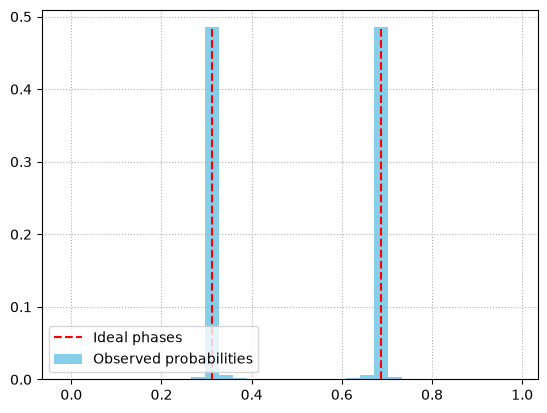

In [7]:
import matplotlib.pyplot as plt

exp_vals = tuple(calculate_expected_phases(ws, bits_of_precision, basis_state, 2 ** state_reg.num_qubits))
print(exp_vals)

plt.bar(
    probabilities.keys(),
    probabilities.values(),
    width=1/(2 ** (phases_reg.num_qubits)),
    label="Observed probabilities",
    color="skyblue",
)
plt.vlines(exp_vals, 0, max(probabilities.values()), linestyle="--", color="r", lw=1.5, label="Ideal phases")
plt.grid(linestyle=":")
plt.legend(loc=3)
plt.show()

Looks good! Now all that remains is to print out the ideal energy for our system to compare it with our final answer:

In [8]:
ideal_energy = calculate_expected_energy(ws, basis_state, 2**state_reg.num_qubits)

print(f"Ideal energy: {ideal_energy}")
print(f"Measured energy: {observed_energy}")

Ideal energy: -0.4
Measured energy: -0.3826834323650897


## Part III conclusion

In the third part of this kata, you've seen how to implement a qubitization iterate of our Hamiltonian and use it to estimate the energy of an eigenstate.

It's worth taking a look at how far we've come in the first three parts of this kata:

- We picked a system to investigate, starting from a drawing of a ring and deriving a Hamiltonian that describes the dynamics we want.
- We encoded it using a qubitized block encoding by defining PREPARE and SELECT unitaries.
- We compiled the high-level subroutines down to easily-managed chunks like adders, data loaders and state preparation routines.
- We then compiled _those_ down to the gate level, testing everything rigorously as we went.
- Finally, we passed the whole thing into QPE to obtain the final energy estimates and validated those as well.

These steps are not unique to the (admittedly contrived) system we've studied in this kata. They are applicable to a huge class of problems across a broad array of domains. We hope you will take the lessons from this kata and apply them to your own problems in the future!

Next, in [part IV](./QubitizedHamiltonianQPE_4_QRE.ipynb), you will learn to perform the basic resource analysis of our implementation and use the results to optimize it.